<a href="https://colab.research.google.com/github/jturaj1/ai-stuff/blob/main/Lab02_JakubTuraj7876.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("Tensorflow version:", tf.__version__)

Tensorflow version: 2.19.0


In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)
print("label examples:", y_train[:10])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
label examples: [5 0 4 1 9 2 1 3 1 4]


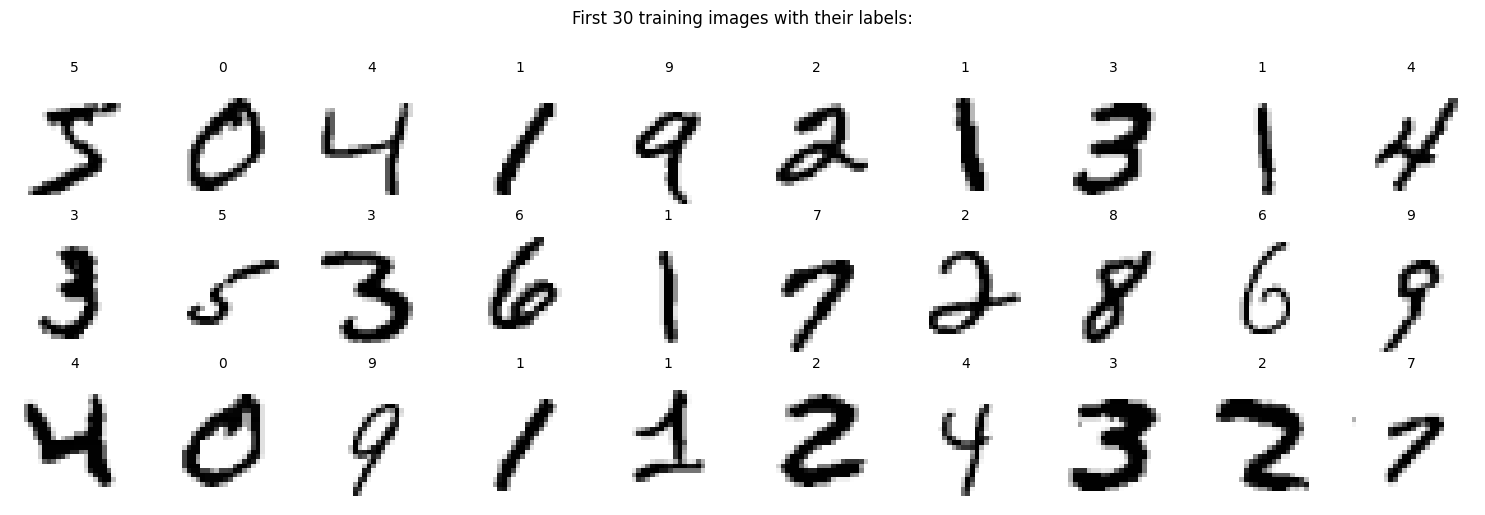

In [4]:
fig, axes = plt.subplots(3, 10, figsize=(15,5))

for i, ax in enumerate(axes.flat):
  ax.imshow(X_train[i], cmap='gray_r')
  ax.set_title(str(y_train[i]), fontsize=10)
  ax.axis('off')

plt.suptitle("First 30 training images with their labels:", y=1.02)
plt.tight_layout()
plt.show()

In [5]:
sample = X_train[0]
print("Shape:", sample.shape)
print("Min pixel value:", sample.min())
print("Max pixel value:", sample.max())
print("Data type:", sample.dtype)

print("\nTop-left 8x8 cornerof the image:")
print(sample[:8, :8])

Shape: (28, 28)
Min pixel value: 0
Max pixel value: 255
Data type: uint8

Top-left 8x8 cornerof the image:
[[ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 49]]


In [6]:
X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)
print("Before reshape:", X_train.shape)
print("After reshape:", X_train_flat.shape)

Before reshape: (60000, 28, 28)
After reshape: (60000, 784)


In [7]:
X_train_norm = X_train_flat.astype('float32') / 255
X_test_norm = X_test_flat.astype('float32') / 255

print("Before normalization — min:", X_train_flat.min(), "max:", X_train_flat.max())
print("After normalization  — min:", X_train_norm.min(), "max:", X_train_norm.max())

Before normalization — min: 0 max: 255
After normalization  — min: 0.0 max: 1.0


In [8]:
y_train_ohe = keras.utils.to_categorical(y_train, num_classes=10)
y_test_ohe = keras.utils.to_categorical(y_test, num_classes=10)

print("Before one-hot:", y_train[2])
print("After one-hot:", y_train_ohe[2])
print("Shape:", y_train_ohe.shape)

Before one-hot: 4
After one-hot: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
Shape: (60000, 10)


In [9]:
raw_outputs = np.array([1.2, 0.3, 3.1, 0.7, 0.1, 0.5, 0.2, 0.1, 0.9, 0.4])
exp_outputs = np.exp(raw_outputs)
softmax_outputs = exp_outputs / exp_outputs.sum()

print("Raw outputs:", np.round(raw_outputs, 2))
print("Softmax outputs:", np.round(softmax_outputs, 3))
print("Softmax outputs sum:", softmax_outputs.sum())
print("Predicted class:", np.argmax(softmax_outputs))

Raw outputs: [1.2 0.3 3.1 0.7 0.1 0.5 0.2 0.1 0.9 0.4]
Softmax outputs: [0.088 0.036 0.585 0.053 0.029 0.043 0.032 0.029 0.065 0.039]
Softmax outputs sum: 1.0000000000000002
Predicted class: 2


In [10]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    X_train_norm, y_train_ohe,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8258 - loss: 0.6293 - val_accuracy: 0.9612 - val_loss: 0.1413
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9534 - loss: 0.1589 - val_accuracy: 0.9633 - val_loss: 0.1232
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9692 - loss: 0.1036 - val_accuracy: 0.9727 - val_loss: 0.0971
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9769 - loss: 0.0765 - val_accuracy: 0.9758 - val_loss: 0.0823
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9842 - loss: 0.0550 - val_accuracy: 0.9782 - val_loss: 0.0772
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9859 - loss: 0.0461 - val_accuracy: 0.9775 - val_loss: 0.0760
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9880 - loss: 0.0382 - val_accuracy: 0.9760 - val_loss: 0.0859
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9898 - loss: 0.0324 - val_accuracy: 0.

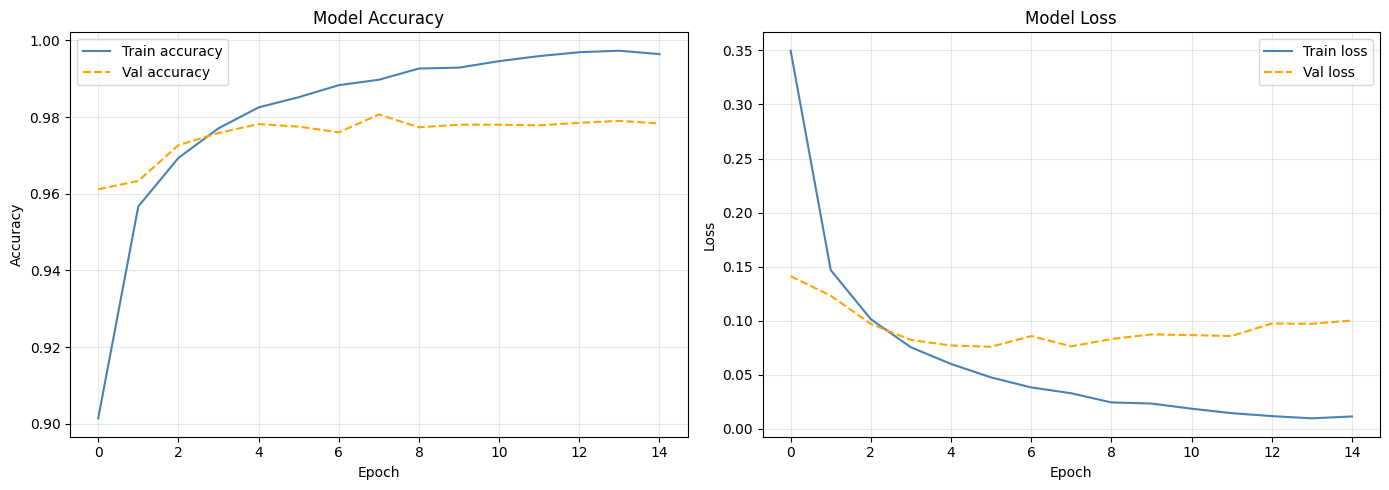

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train accuracy', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Val accuracy', color='orange', linestyle='--')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train loss', color='steelblue')
ax2.plot(history.history['val_loss'], label='Val loss', color='orange', linestyle='--')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_ohe, verbose=0)
print(f"Test loss:{test_loss:.4f}")
print(f"Test accuracy:{test_accuracy:.4f}")

Test loss:0.0909
Test accuracy:0.9778


In [15]:
predictions = model.predict(X_test_norm)
print("Raw output for first test image:")
print(np.round(predictions[0], 4))
print("Predicted class:", np.argmax(predictions[0]))
print("True class:     ", y_test[0])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Raw output for first test image:
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Predicted class: 7
True class:      7


Total mistakes: 222 out of 10000


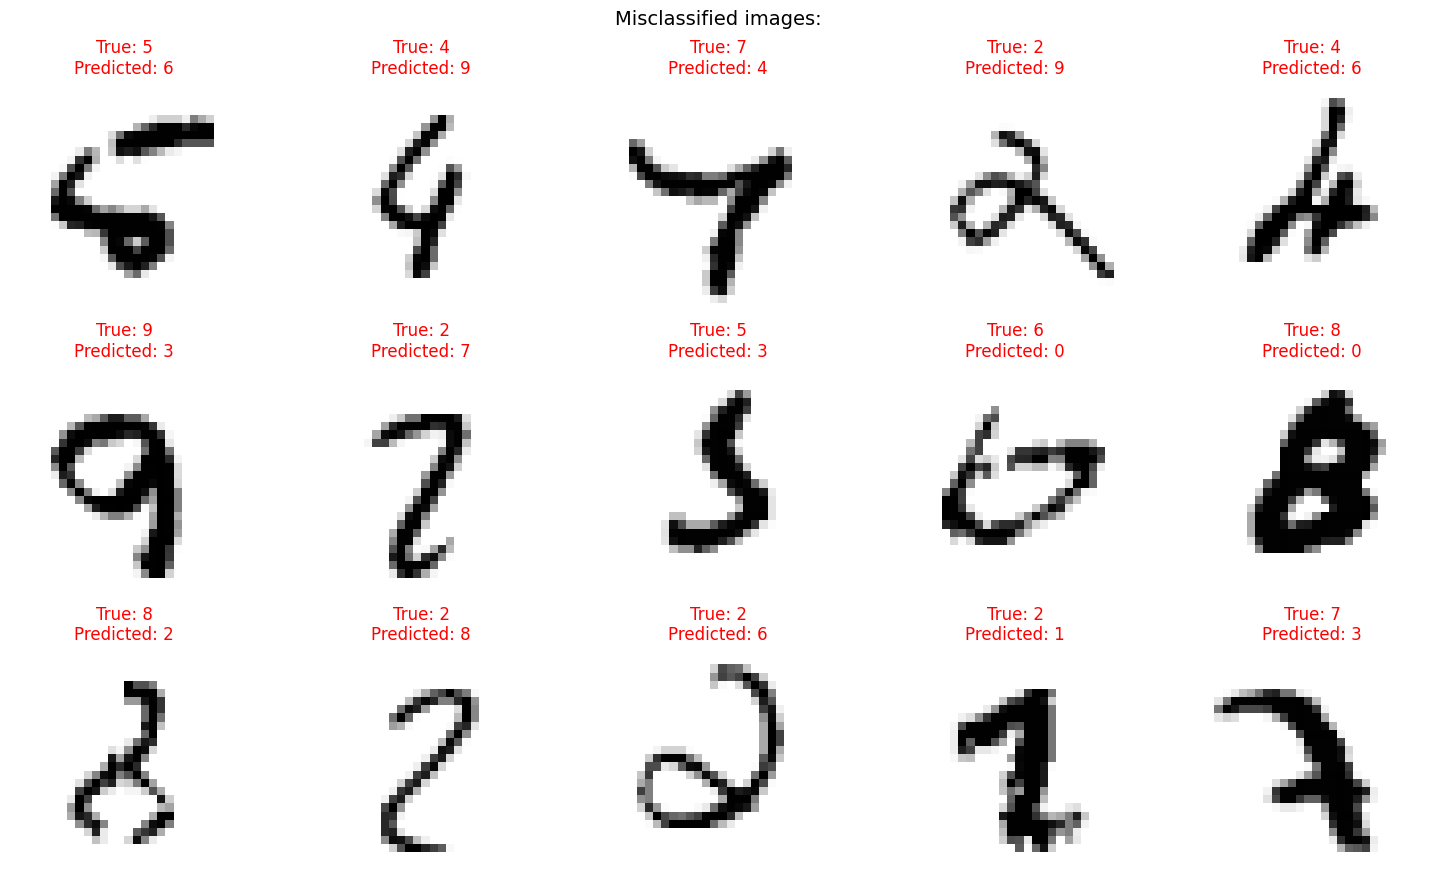

In [16]:
predicted_classes = np.argmax(predictions, axis=1)

mistakes = np.where(predicted_classes != y_test)[0]
print(f"Total mistakes: {len(mistakes)} out of {len(y_test)}")

fig, axes = plt.subplots(3, 5, figsize=(15,9))

for i, ax in enumerate(axes.flat):
  idx = mistakes[i]
  ax.imshow(X_test[idx], cmap='gray_r')
  ax.set_title(
        f"True: {y_test[idx]}\nPredicted: {predicted_classes[idx]}",
        color='red'
    )
  ax.axis('off')

plt.suptitle("Misclassified images:", fontsize=14)
plt.tight_layout()
plt.show()

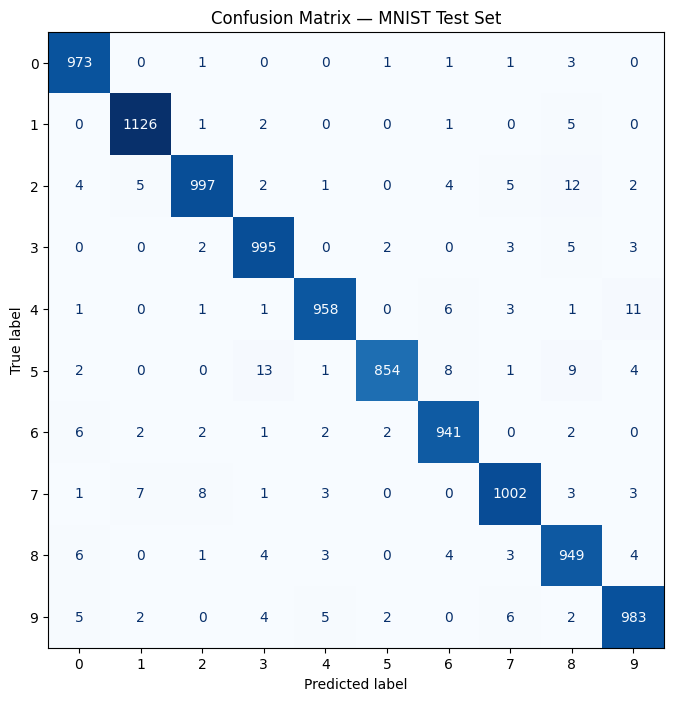

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(range(10)))

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — MNIST Test Set')
plt.show()

In [18]:
history_new = model.fit(
    X_train_norm, y_train_ohe,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9969 - loss: 0.0097 - val_accuracy: 0.9788 - val_loss: 0.1039
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9965 - loss: 0.0107 - val_accuracy: 0.9800 - val_loss: 0.0942
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9979 - loss: 0.0068 - val_accuracy: 0.9803 - val_loss: 0.1032
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9988 - loss: 0.0051 - val_accuracy: 0.9802 - val_loss: 0.1073
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9992 - loss: 0.0036 - val_accuracy: 0.9777 - val_loss: 0.1118


In [19]:
history_new = model.fit(
    X_train_norm, y_train_ohe,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9790 - loss: 0.0717 - val_accuracy: 0.9762 - val_loss: 0.1199
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9931 - loss: 0.0204 - val_accuracy: 0.9743 - val_loss: 0.1222
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9930 - loss: 0.0206 - val_accuracy: 0.9760 - val_loss: 0.1229
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9938 - loss: 0.0184 - val_accuracy: 0.9700 - val_loss: 0.1394
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9919 - loss: 0.0211 - val_accuracy: 0.9767 - val_loss: 0.1112
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9947 - loss: 0.0158 - val_accuracy: 0.9778 - val_loss: 0.1133
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9964 - loss: 0.0110 - val_accuracy: 0.9773 - val_loss: 0.1293
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9955 - loss: 0.0132 - 

The time to process each epoch takes longer.

In [21]:
confidences = np.max(predictions, axis=1)

print("First 10 prediction confidences:")
print(np.round(confidences[:10], 4))

First 10 prediction confidences:
[1.     1.     0.9998 1.     1.     1.     1.     0.9898 0.6093 1.    ]


In [23]:
min_confidences = np.argsort(confidences)[:10]
print("Indices of 10 predictions with lowest confidence:")
print(min_confidences)

Indices of 10 predictions with lowest confidence:
[1232 2414  956 6625 1182 7921 9225 2979 5600 9664]


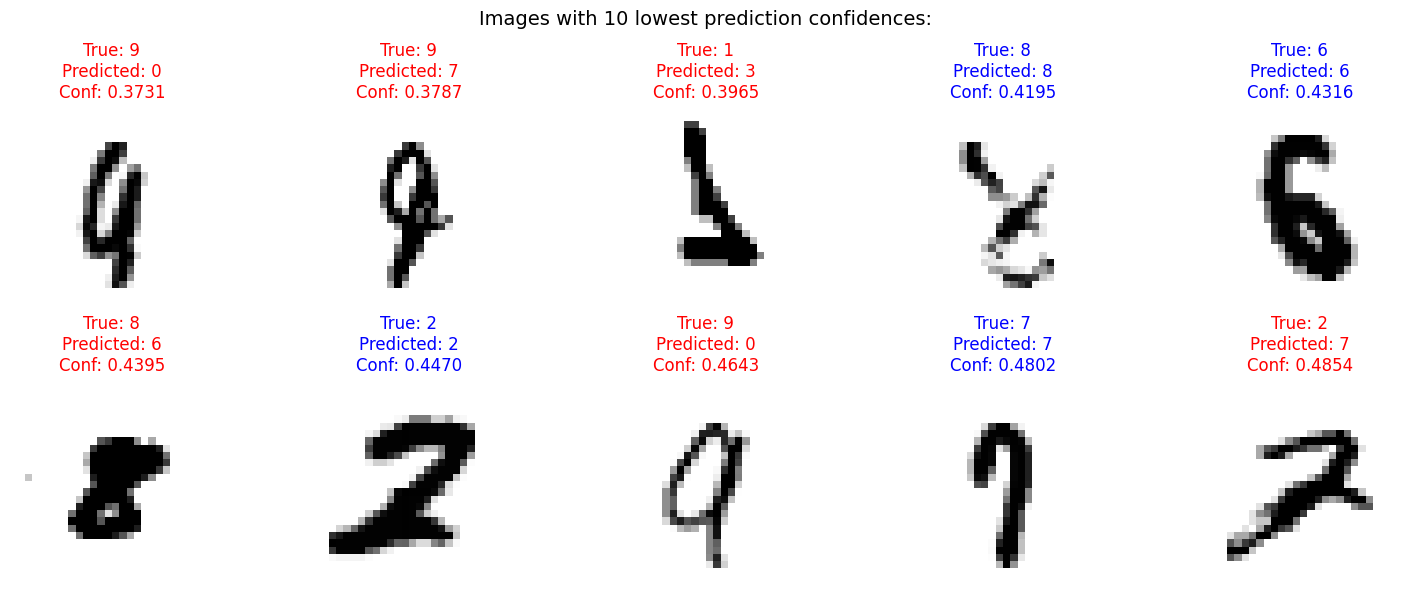

In [25]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
  idx = min_confidences[i]
  ax.imshow(X_test[idx], cmap='gray_r')
  ax.set_title(
        f"True: {y_test[idx]}\nPredicted: {predicted_classes[idx]}\nConf: {confidences[idx]:.4f}",
        color='blue' if y_test[idx] == predicted_classes[idx] else 'red'
    )
  ax.axis('off')

plt.suptitle("Images with 10 lowest prediction confidences:", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(32, activation='sigmoid'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
per_class_accuracy = []
num_classes = cm.shape[0]

for i in range(num_classes):
    true_positives = cm[i, i]
    total_instances = np.sum(cm[i, :])
    accuracy = true_positives / total_instances if total_instances > 0 else 0
    per_class_accuracy.append(accuracy)
    print(f"Accuracy for class {i}: {accuracy:.4f}")

print("\n--- Percentage of correctly classified images ---")
total_correct_predictions = np.sum(np.diag(cm))
total_predictions = np.sum(cm)
overall_correct_percentage = (total_correct_predictions / total_predictions) * 100
print(f"Overall percentage of correctly classified images: {overall_correct_percentage:.2f}%")

Accuracy for class 0: 0.9929
Accuracy for class 1: 0.9921
Accuracy for class 2: 0.9661
Accuracy for class 3: 0.9851
Accuracy for class 4: 0.9756
Accuracy for class 5: 0.9574
Accuracy for class 6: 0.9823
Accuracy for class 7: 0.9747
Accuracy for class 8: 0.9743
Accuracy for class 9: 0.9742

--- Percentage of correctly classified images ---
Overall percentage of correctly classified images: 97.78%


0 is the easiest digit to classify for the model. The hardest to classify is 5.